 ETL Process - Global Supply Chain Risk & Logistics Analysis (2024-2026)

## Objective
 This notebook performs the ETL process for the supply chain dataset. The goal is to extract the raw data, transform it by cleaning and standardizing values, and load the processed dataset for further analysis in EDA, clustering, and forecasting.

## ETL Tasks
 - Load raw dataset
 - Inspect structure and data types
 - Check missing values
 - Check duplicates
 - Identify inconsistencies
 - Handle outliers
 - Create cleaned dataset
 - Save processed data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [35]:
df = pd.read_csv("../data/raw/global_supply_chain_risk_2026.csv")
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [36]:
df.shape

(5000, 14)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [38]:
#Descriptive statistics to get an idea on min and max values and possible outliers
df.describe(include='all')

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000,5000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
unique,5000,731,8,9,4,5,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN
top,SC-10000,2024-04-05,Busan,Marseille,Air,Electronics,NaN,NaN,NaN,NaN,Fog,NaN,NaN,NaN
freq,1,16,667,583,1320,1016,NaN,NaN,NaN,NaN,1036,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,7704.063888,246.252052,2.854552,5.076900,NaN,0.754387,19.355386,0.612600
std,NaN,NaN,NaN,NaN,NaN,NaN,4199.687885,142.522591,0.959533,2.877832,NaN,0.144363,31.405143,0.487205
min,NaN,NaN,NaN,NaN,NaN,NaN,500.170000,1.030000,1.200000,0.000000,NaN,0.500000,0.500000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,4036.010000,124.330000,2.020000,2.600000,NaN,0.629000,2.110000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,7750.125000,243.500000,2.840000,5.100000,NaN,0.757000,8.245000,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,11347.462500,366.955000,3.710000,7.500000,NaN,0.879000,21.207500,1.000000


In [39]:
#Check missing values
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
#To get an idea on whats in the each data column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10])


Column: Shipment_ID
<StringArray>
['SC-10000', 'SC-10001', 'SC-10002', 'SC-10003', 'SC-10004', 'SC-10005',
 'SC-10006', 'SC-10007', 'SC-10008', 'SC-10009']
Length: 10, dtype: str

Column: Date
<StringArray>
['2025-10-16', '2024-04-24', '2024-01-26', '2024-10-08', '2024-09-07',
 '2024-08-16', '2024-05-22', '2024-04-14', '2025-11-23', '2025-07-12']
Length: 10, dtype: str

Column: Origin_Port
<StringArray>
[  'Singapore',   'Rotterdam',       'Busan',    'Shanghai',       'Dubai',
 'Los Angeles',     'Hamburg',     'Antwerp']
Length: 8, dtype: str

Column: Destination_Port
<StringArray>
['Los Angeles',    'Shanghai',     'Hamburg',   'Singapore',   'Marseille',
     'Antwerp',   'Rotterdam',       'Busan',       'Dubai']
Length: 9, dtype: str

Column: Transport_Mode
<StringArray>
['Rail', 'Air', 'Road', 'Sea']
Length: 4, dtype: str

Column: Product_Category
<StringArray>
['Textiles', 'Automotive', 'Perishables', 'Electronics', 'Pharmaceuticals']
Length: 5, dtype: str

Column: Distance_km

In [42]:
#Convert the Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [43]:
df['Date'].head()

0   2025-10-16
1   2024-04-24
2   2024-01-26
3   2024-10-08
4   2024-09-07
Name: Date, dtype: datetime64[us]

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   str           
 1   Date                       5000 non-null   datetime64[us]
 2   Origin_Port                5000 non-null   str           
 3   Destination_Port           5000 non-null   str           
 4   Transport_Mode             5000 non-null   str           
 5   Product_Category           5000 non-null   str           
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   str           
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_Time_Days   

In [45]:
#Rechecking missing values after date conversion
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [46]:
#Rechecking duplicates after date conversion
df.duplicated().sum()

np.int64(0)

In [47]:
#Create a temporary df copy
df_clean = df.copy()

In [48]:
#Filterout numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Distance_km',
 'Weight_MT',
 'Fuel_Price_Index',
 'Geopolitical_Risk_Score',
 'Carrier_Reliability_Score',
 'Lead_Time_Days',
 'Disruption_Occurred']

In [49]:
#Descriptive statistics on filtered numeric columns
df_clean[numeric_cols].describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


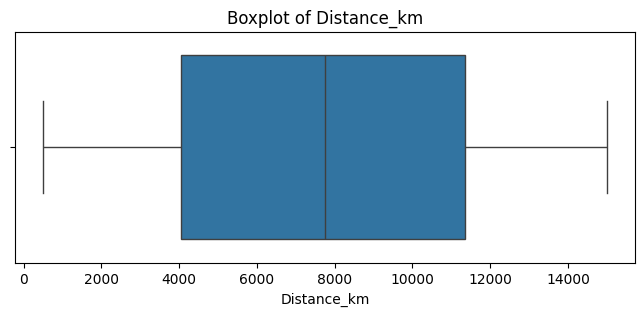

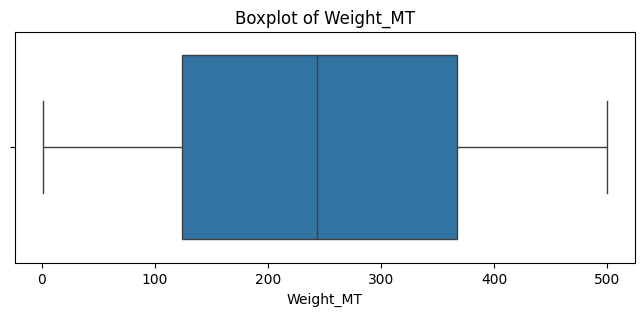

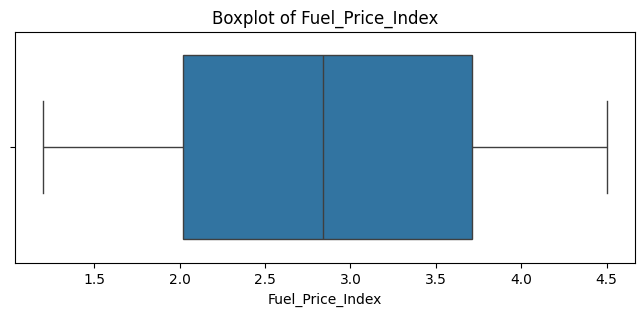

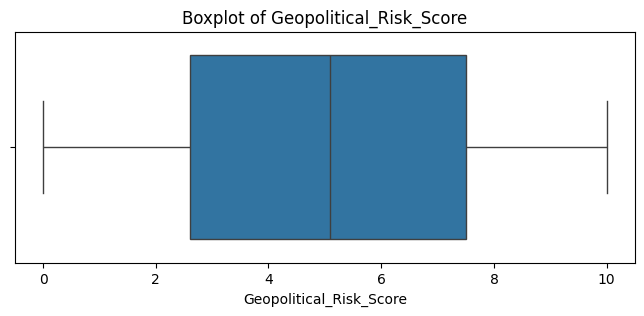

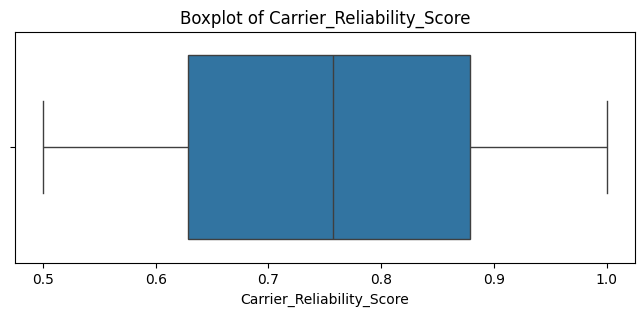

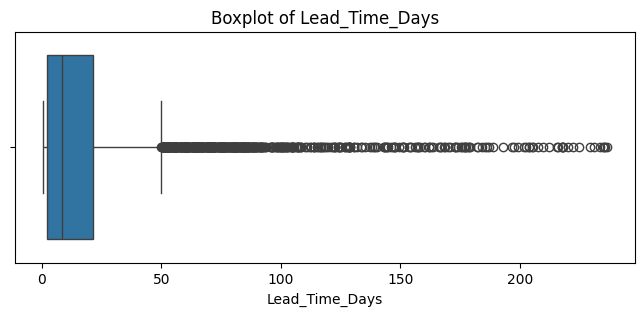

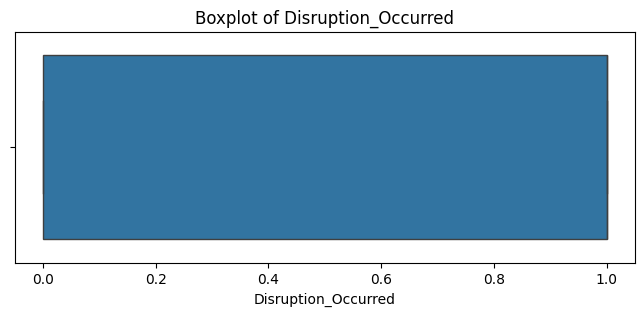

In [50]:
#Create boxplots for outlier detection
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [51]:
#Date transformation for later EDA
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
df_clean['Quarter'] = df_clean['Date'].dt.quarter

In [52]:
df_clean.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Month_Name,Quarter
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,2025,10,October,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,2024,4,April,2
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2024,1,January,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,2024,10,October,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,2024,9,September,3


In [53]:
#Saving the df as a CSV file
df_clean.to_csv("../data/processed/cleaned_supply_chain_data.csv", index=False)

## Initial ETL Summary

The following ETL actions were completed in this stage:

- Loaded the raw supply chain dataset
- Inspected dimensions, columns, data types, and summary statistics
- Assessed for missing values
    No missing entries were identified across all variables
- Assessed for duplicate records
    No duplicated entries were identified
- Converted the Date column into datetime format
    Successfully converted without any null values
- Assessed agin for duplicate records after the date conversion
- Performed outlier analysis using boxplots
- Created new time based columns (Year, Month, Quarter)
- Saved the cleaned dataset as a CSV


## Outlier Analysis

Outlier analysis was conducted using boxplots for all numerical variables. 
Most variables showed reasonable distributions without extreme values.

However, the "Lead_Time_Days" variable contained significant high-value outliers. 
These values may represent real world supply chain disruptions such as delays caused by geopolitical risks or logistical inefficiencies.

Instead of removing these values, a capping approach was applied to limit extreme values while preserving the integrity of the dataset.

In [54]:
#Outlier capping - IQR method
Q1 = df_clean['Lead_Time_Days'].quantile(0.25)
Q3 = df_clean['Lead_Time_Days'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['Lead_Time_Days'] = np.where(
    df_clean['Lead_Time_Days'] > upper_bound,
    upper_bound,
    df_clean['Lead_Time_Days']
)

df_clean['Lead_Time_Days'] = np.where(
    df_clean['Lead_Time_Days'] < lower_bound,
    lower_bound,
    df_clean['Lead_Time_Days']
)

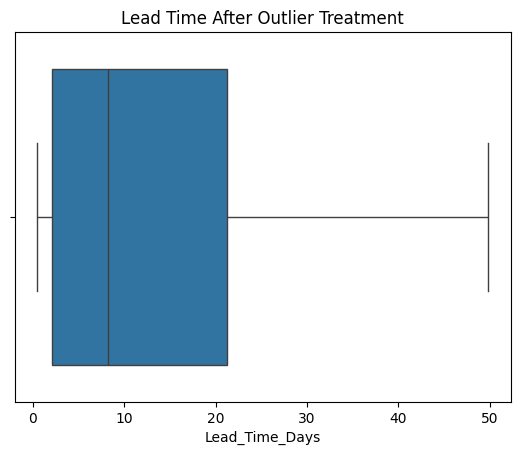

In [55]:
sns.boxplot(x=df_clean['Lead_Time_Days'])
plt.title("Lead Time After Outlier Treatment")
plt.show()

In [56]:
df_clean['Disruption_Occurred'].unique()

array([1, 0])

In [ ]:
#Update the cleaned_supply_chain_data.csv file
df_clean.to_csv("../data/processed/cleaned_supply_chain_data.csv", index=False)

## Final ETL Summary

The ETL process was completed as follows:

- Extracted raw dataset from CSV file
- Verified dataset dimensions and structure (5000 rows, 14 columns)
- Confirmed no missing values across all variables
- Confirmed absence of duplicate records
- Converted Date column into datetime format
- Performed outlier analysis using boxplots
- Created new time based columns (Year, Month, Quarter)
- Applied outlier capping to Lead_Time_Days using the IQR method
- Updated the cleaned dataset file
